## - Título y Descripción

# ☀️ Start Energy AI - Análisis Exploratorio de Datos (EDA)
* **Proyecto:** Predicción de Generación Fotovoltaica y Optimización de Consumo.
* **Autores:** Camila Rabelo
* **Descripción:** Este notebook contiene la fase de carga, limpieza, análisis estadístico y visualización de los datos energéticos y meteorológicos.

## - Importar librerías

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

## - Dataset 

In [32]:
# [NOTA]: Cuando tengáis el CSV real, sustituid este bloque por: 
# df = pd.read_csv('../data/vuestro_archivo.csv')

# Generamos datos temporales de prueba (un mes)

fechas = pd.date_range(
    start='2023-05-01',
    end='2023-05-31 23:00:00',
    freq='h'
)
np.random.seed(42)
horas = fechas.hour

radiacion_simulada = np.maximum(0, np.sin((horas - 6) * np.pi / 12) * 1000 + np.random.normal(0, 50, len(fechas)))
generacion_solar = radiacion_simulada * 0.85 
consumo_hogar = np.random.normal(400, 100, len(fechas)) + (horas.isin([8, 9, 20, 21]) * 300)

df = pd.DataFrame({
    'timestamp': fechas,
    'radiacion_solar': radiacion_simulada,
    'generacion_solar': generacion_solar,
    'consumo_hogar': consumo_hogar
})

# Establecer la fecha como índice de la serie temporal
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df.head()

,radiacion_solar,generacion_solar,consumo_hogar
timestamp,,,
2023-05-01 00:00:00,0.0,0.0,451.765902
2023-05-01 01:00:00,0.0,0.0,327.425619
2023-05-01 02:00:00,0.0,0.0,418.676676
2023-05-01 03:00:00,0.0,0.0,324.461707
2023-05-01 04:00:00,0.0,0.0,338.848220


## 1. Limpieza y Verificación de Nulos
Comprobamos la integridad del dataset, tipos de datos y posibles valores vacíos que puedan alterar el modelo.

In [33]:
print("--- TIPOS DE DATOS ---")
print(df.dtypes)
print("\n--- VALORES NULOS POR COLUMNA ---")
print(df.isnull().sum())

# Tratamiento preventivo de nulos (si los hubiera)
df.fillna(method='ffill', inplace=True)

--- TIPOS DE DATOS ---
radiacion_solar     float64
generacion_solar    float64
consumo_hogar       float64
dtype: object

--- VALORES NULOS POR COLUMNA ---
radiacion_solar     0
generacion_solar    0
consumo_hogar       0
dtype: int64


C:\Users\Santiago\AppData\Local\Temp\ipykernel_11992\2271730829.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## - Comprobación de nulos y tipos de datos (ETL básico).

In [34]:
# Verificar si hay valores nulos y los tipos de datos

print("---VALORES NULOS ---")
print(df.isnull().sum())
print("\n--- INFORMACIÑIN DEL DATAFRAME ---")
print(df.info())


---VALORES NULOS ---
radiacion_solar     0
generacion_solar    0
consumo_hogar       0
dtype: int64

--- INFORMACIÑIN DEL DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 744 entries, 2023-05-01 00:00:00 to 2023-05-31 23:00:00
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   radiacion_solar   744 non-null    float64
 1   generacion_solar  744 non-null    float64
 2   consumo_hogar     744 non-null    float64
dtypes: float64(3)
memory usage: 23.2 KB
None


## 2. Análisis Estadístico Descriptivo
Evaluamos los valores medios, máximos y desviaciones típicas de la generación y el consumo energético.

- Gráfica de prueba (Curva de Generación vs Consumo).

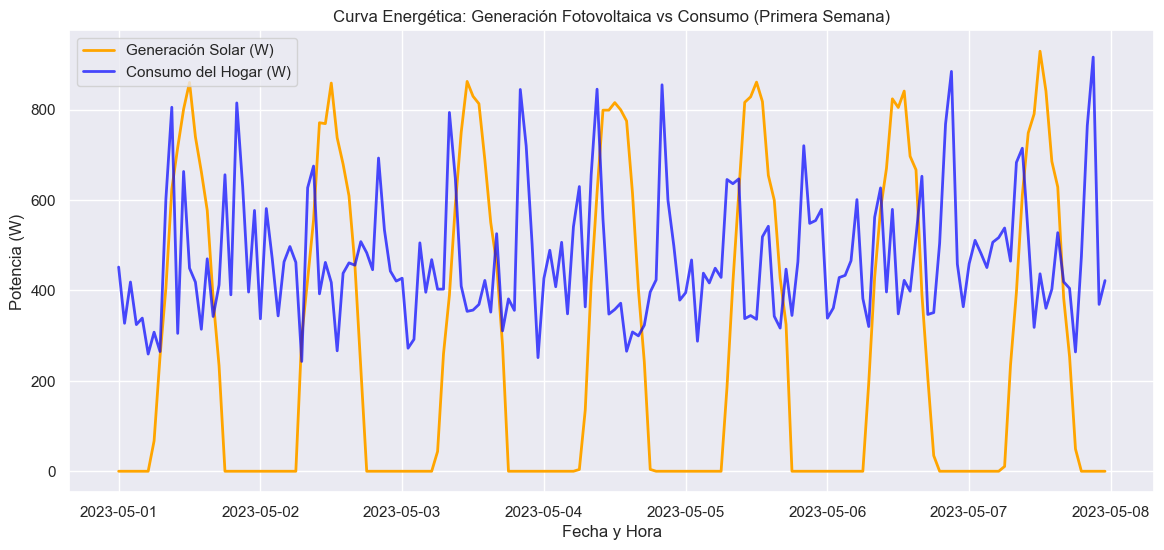

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    df.index[:168],
    df['generacion_solar'][:168],
    label='Generación Solar (W)',
    color='orange',
    linewidth=2
)

plt.plot(
    df.index[:168],
    df['consumo_hogar'][:168],
    label='Consumo del Hogar (W)',
    color='blue',
    linewidth=2,
    alpha=0.7
)

plt.title('Curva Energética: Generación Fotovoltaica vs Consumo (Primera Semana)')
plt.xlabel('Fecha y Hora')
plt.ylabel('Potencia (W)')
plt.legend()
plt.grid(True)

plt.show()

In [36]:
print(plt)

<module 'matplotlib.pyplot' from 'c:\\Users\\Santiago\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>


In [38]:
#Estadísticas básicas
df.describe()

,radiacion_solar,generacion_solar,consumo_hogar
count,744.000000,744.000000,744.000000
mean,318.687300,270.884205,459.999532
std,386.921151,328.882979,146.230472
min,0.000000,0.000000,115.145738
25%,0.000000,0.000000,359.522616
50%,4.720958,4.012814,434.927964
75%,718.124603,610.405912,534.531441
max,1106.107810,940.191638,957.970934


## 3. Visualización de Datos (Gráficas)
Analizamos visualmente cómo se comportan la generación fotovoltaica frente al consumo del hogar.

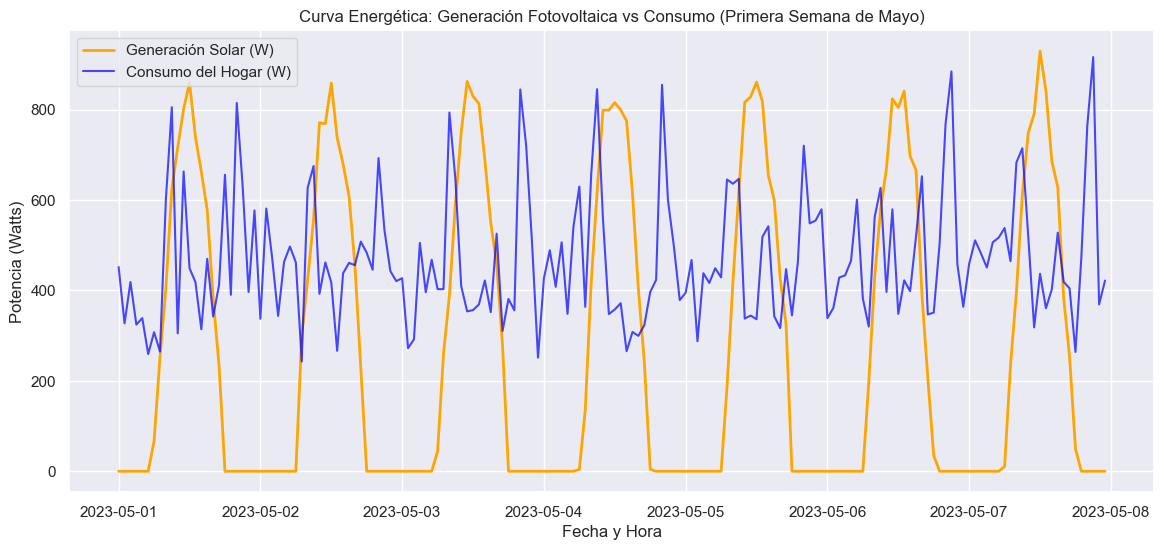

In [40]:
#Gráfica de líneas de la primera semana
plt.figure(figsize=(14, 6))
plt.plot(df.index[:168], df['generacion_solar'][:168], label='Generación Solar (W)', color='orange', linewidth=2)
plt.plot(df.index[:168], df['consumo_hogar'][:168], label='Consumo del Hogar (W)', color='blue', alpha=0.7, linewidth=1.5)
plt.title('Curva Energética: Generación Fotovoltaica vs Consumo (Primera Semana de Mayo)')
plt.xlabel('Fecha y Hora')
plt.ylabel('Potencia (Watts)')
plt.legend()
plt.show()

## 4. Ingeniería de Características (Feature Engineering)
Creamos nuevas variables temporales (hora del día y mes) para estructurar mejor el comportamiento energético.

In [41]:
#Extracción de variables de tiempo
df['hora'] = df.index.hour
df['mes'] = df.index.month

# Ejemplo de media de generación según la hora del dia
generacion_por_hora = df.groupby('hora')['generacion_solar'].mean()
print(generacion_por_hora)

hora
0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
5       0.000000
6      16.071330
7     215.099331
8     424.220949
9     610.494768
10    736.091768
11    826.998652
12    849.407220
13    811.000281
14    731.181719
15    603.653544
16    414.438198
17    240.375018
18     22.188143
19      0.000000
20      0.000000
21      0.000000
22      0.000000
23      0.000000
Name: generacion_solar, dtype: float64


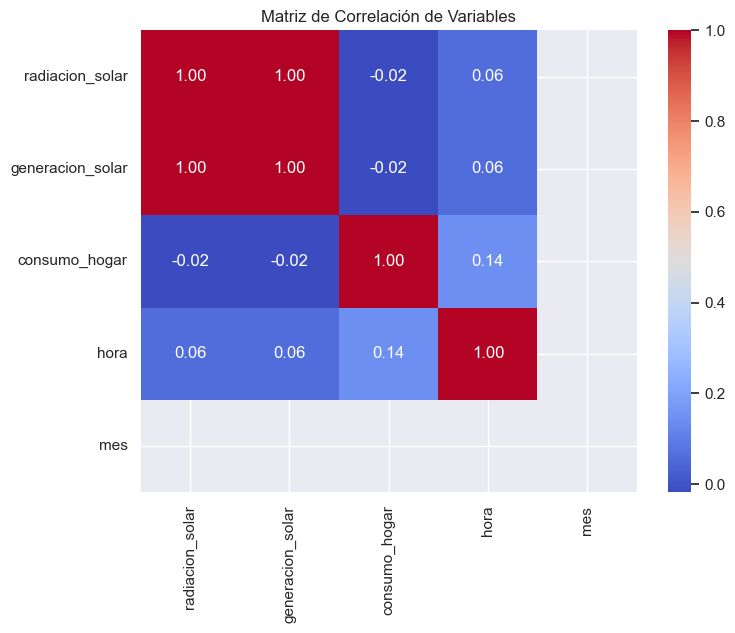

In [42]:
#Mapa de Calor de Correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables')
plt.show()

## 5. Conclusiones del EDA
* **Excedentes:** Se comprueba que las horas centrales del día acumulan la mayor parte de la producción solar, superando el consumo base del hogar.
* **Aplicación:** Estos patrones justifican la integración de alertas inteligentes en el dashboard web (`index.html`) para incentivar el consumo en horas de alta radiación.